In [1]:
import warnings 
warnings.filterwarnings("ignore")

In [2]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt

### Citation Data

In [5]:
# load the dataset
file_path = "./APS Data/aps-dataset-citations-2022.csv"
df = pd.read_csv(file_path)

# display the first few rows of the dataset
print("First few rows of the dataset:")
print(df.head())
print()

# total number of citations
total_citations = len(df)
print(f"Total number of citations: {total_citations}")
print()

# check for any duplicate entries
duplicate_entries = df.duplicated().sum()
print(f"Number of duplicate entries: {duplicate_entries}")
print()

# check for any missing values
print("Missing values in the dataset:")
print(df.isnull().sum())
print()

# number of unique citing DOIs
unique_citing_dois = df['citing_doi'].nunique()
print(f"Number of unique citing DOIs: {unique_citing_dois}")
print()

# number of unique cited DOIs
unique_cited_dois = df['cited_doi'].nunique()
print(f"Number of unique cited DOIs: {unique_cited_dois}")
print()

# most frequently citing papers
most_citing = df['citing_doi'].value_counts().head(3)
print("Most frequently citing papers:")
print(most_citing)
print()

# most frequently cited papers
most_cited = df['cited_doi'].value_counts().head(3)
print("Most frequently cited papers:")
print(most_cited)
print()

# citation distribution (citing DOIs)
citation_distribution_citing = df['citing_doi'].value_counts()
print("Citation distribution for citing DOIs:")
print(citation_distribution_citing.describe())
print()

# citation distribution (cited DOIs)
citation_distribution_cited = df['cited_doi'].value_counts()
print("Citation distribution for cited DOIs:")
print(citation_distribution_cited.describe())

First few rows of the dataset:
                      citing_doi                     cited_doi
0  10.1103/PhysRevSeriesI.11.215    10.1103/PhysRevSeriesI.1.1
1  10.1103/PhysRevSeriesI.12.121  10.1103/PhysRevSeriesI.1.166
2    10.1103/PhysRevSeriesI.7.93  10.1103/PhysRevSeriesI.1.166
3  10.1103/PhysRevSeriesI.16.267   10.1103/PhysRevSeriesI.2.35
4   10.1103/PhysRevSeriesI.17.65  10.1103/PhysRevSeriesI.2.112

Total number of citations: 9833191

Number of duplicate entries: 0

Missing values in the dataset:
citing_doi    0
cited_doi     0
dtype: int64

Number of unique citing DOIs: 693706

Number of unique cited DOIs: 625223

Most frequently citing papers:
citing_doi
10.1103/RevModPhys.83.471       607
10.1103/RevModPhys.70.1039      582
10.1103/RevModPhys.90.025008    573
Name: count, dtype: int64

Most frequently cited papers:
cited_doi
10.1103/PhysRevLett.77.3865    14357
10.1103/PhysRevB.54.11169       9984
10.1103/PhysRev.140.A1133       8588
Name: count, dtype: int64

Citation distri

### Metadata

In [7]:
# directory path
metadata_directory = "./APS Data/aps-dataset-metadata-2022"
print(os.listdir(metadata_directory))

['PR', 'PRA', 'PRAB', 'PRAPPLIED', 'PRB', 'PRC', 'PRD', 'PRE', 'PRFLUIDS', 'PRI', 'PRL', 'PRMATERIALS', 'PRPER', 'PRRESEARCH', 'PRSTAB', 'PRSTPER', 'PRX', 'PRXENERGY', 'PRXQUANTUM', 'RMP']


In [10]:
# function to load metadata from JSON source files
def load_metadata(directory):
    metadata = []

    # traverse through journal folders
    for journal_folder in os.listdir(directory):
        journal_folder_path = os.path.join(directory, journal_folder)
        if os.path.isdir(journal_folder_path):
            # traverse through numbered folders within each journal folder
            for numbered_folder in os.listdir(journal_folder_path):
                numbered_folder_path = os.path.join(journal_folder_path, numbered_folder)
                if os.path.isdir(numbered_folder_path):
                    # traverse through JSON files within each numbered folder
                    for file in os.listdir(numbered_folder_path):
                        if file.endswith(".json"):
                            file_path = os.path.join(numbered_folder_path, file)
                            # load JSON source file
                            with open(file_path, 'r') as f:
                                # read the contents of the source file
                                json_data = f.read()
                                # parse JSON data
                                metadata_json = json.loads(json_data)
                            # append metadata to list
                            metadata.append(metadata_json)

    if not metadata:
        print("No JSON source files found in the specified directory or its subdirectories.")
        return None

    # convert metadata list to DataFrame
    metadata_df = pd.DataFrame(metadata)
    return metadata_df

# load metadata
metadata_df = load_metadata(metadata_directory)

In [ ]:
metadata_df.to_csv("./APS Data/metadata.csv", index=False)

In [8]:
metadata = pd.read_csv('./APS Data/metadata.csv')

In [25]:
print(metadata)

                                  id  \
0                10.1103/PhysRev.1.1   
1              10.1103/PhysRev.1.124   
2              10.1103/PhysRev.1.141   
3              10.1103/PhysRev.1.154   
4               10.1103/PhysRev.1.16   
...                              ...   
720530  10.1103/RevModPhys.94.045004   
720531  10.1103/RevModPhys.94.045005   
720532  10.1103/RevModPhys.94.045006   
720533  10.1103/RevModPhys.94.045007   
720534  10.1103/RevModPhys.94.045008   

                                                    title        publisher  \
0       {'value': 'Announcement of the Transfer of the...  {'name': 'APS'}   
1       {'value': 'An Absolute Determination of the Vi...  {'name': 'APS'}   
2       {'value': 'Determination of the Heat of Soluti...  {'name': 'APS'}   
3       {'value': 'The Electron Theory of Phosphoresce...  {'name': 'APS'}   
4       {'value': 'The Velocity of Electrons in the Ph...  {'name': 'APS'}   
...                                                

In [26]:
# print shape of the dataset
print("Shape of the dataset:")
print(metadata.shape)
print()

# unique identifiers count
print("Number of unique DOIs:")
print(metadata['id'].nunique())
print()

# display column names and data types
print("Column names and data types:")
print(metadata.dtypes)
print()

# check for missing values in each column
print("Missing values in the dataset:")
print(metadata.isnull().sum())

Shape of the dataset:
(720535, 18)

Number of unique DOIs:
720535

Column names and data types:
id                               object
title                            object
publisher                        object
journal                          object
issue                            object
volume                           object
pageStart                        object
pageEnd                          object
seqnum                          float64
date                     datetime64[ns]
numPages                        float64
articleType                      object
identifiers                      object
rights                           object
authors                          object
affiliations                     object
hasArticleId                     object
classificationSchemes            object
dtype: object

Missing values in the dataset:
id                            0
title                         0
publisher                     0
journal                       0
issue     

In [13]:
# summary statistics for numerical columns
print("Summary statistics for numerical columns:")
print(metadata.describe())
print()

# summary for categorical variables
print("Summary for categorical variable 'articleType':")
print(metadata['articleType'].value_counts())


Summary statistics for numerical columns:
              seqnum       numPages
count  302526.000000  709674.000000
mean        1.024914       7.505057
std         0.212378       6.646182
min         1.000000       0.000000
25%         1.000000       4.000000
50%         1.000000       6.000000
75%         1.000000      10.000000
max        10.000000    1898.000000

Summary for categorical variable 'articleType':
articleType
article             602098
rapid                40159
brief                34972
erratum              15819
reply                 8643
letter-to-editor      8246
comment               5483
letter                2976
editorial              297
announcement            88
nobel                   66
review                  63
essay                   27
perspective             22
retraction              19
tutorial                14
Name: count, dtype: int64


In [17]:
# unique DOIs per journal
print("Unique values and counts for 'journal':")
print(metadata['journal'].value_counts())
print()

Unique values and counts for 'journal':
journal
{'id': 'PRB', 'abbreviatedName': 'Phys. Rev. B', 'name': 'Physical Review B'}                                                                    207609
{'id': 'PRL', 'abbreviatedName': 'Phys. Rev. Lett.', 'name': 'Physical Review Letters'}                                                          133694
{'id': 'PRD', 'abbreviatedName': 'Phys. Rev. D', 'name': 'Physical Review D'}                                                                    103017
{'id': 'PRA', 'abbreviatedName': 'Phys. Rev. A', 'name': 'Physical Review A'}                                                                     88357
{'id': 'PRE', 'abbreviatedName': 'Phys. Rev. E', 'name': 'Physical Review E'}                                                                     65626
{'id': 'PR', 'abbreviatedName': 'Phys. Rev.', 'name': 'Physical Review'}                                                                          47940
{'id': 'PRC', 'abbreviatedName': 'Phys. 

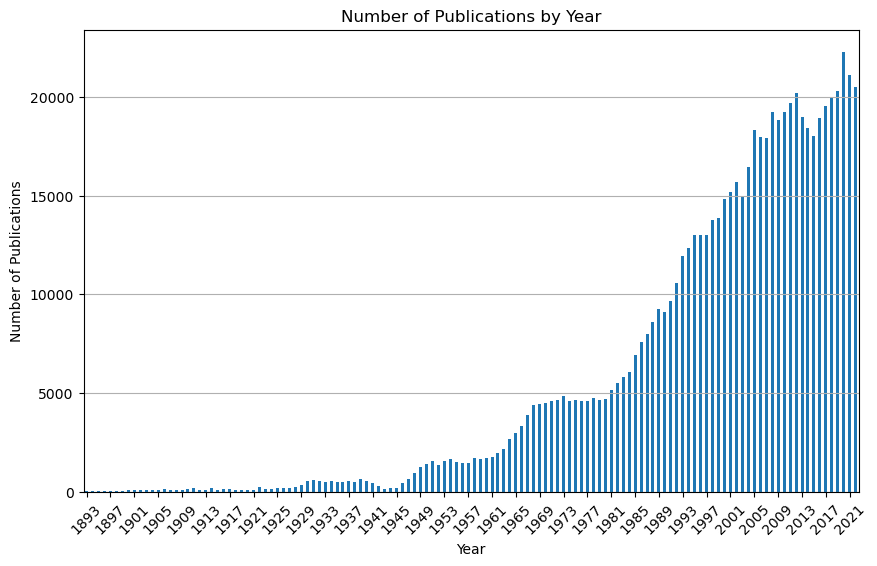

In [24]:
# convert 'date' column to datetime format if needed
metadata['date'] = pd.to_datetime(metadata['date'], errors='coerce')

# plot publications over time
plt.figure(figsize=(10, 6))
publication_counts = metadata['date'].dt.year.value_counts().sort_index()
publication_counts.plot(kind='bar')
plt.title('Number of Publications by Year')
plt.xlabel('Year')
plt.ylabel('Number of Publications')
plt.grid(axis='y')
years = publication_counts.index
plt.xticks(range(0, len(years), 4), years[::4], rotation=45)
plt.show()